In [1]:
from typing import TypedDict

In [2]:
class PortfolioState(TypedDict):
  amount_usd: float
  total_usd: float
  total_inr: float

In [3]:
def calc_total(state:PortfolioState) -> PortfolioState:
  state['total_usd'] = state['amount_usd']*1.08
  return state

In [4]:
def convert_inr(state:PortfolioState) -> PortfolioState :
  state['total_inr'] = state['total_usd']*85
  return state

In [6]:
from langgraph.graph import StateGraph,START,END

builder = StateGraph(PortfolioState)

builder.add_node("calc_total", calc_total)
builder.add_node("convert_inr",convert_inr)

builder.add_edge(START, "calc_total")
builder.add_edge("calc_total","convert_inr")
builder.add_edge("convert_inr",END)


In [7]:
graph = builder.compile()

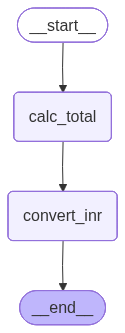

In [8]:
from IPython.display import Image,display

display(graph)